1.

In [31]:
import pandas as pd

df = pd.read_csv('human_activity_selected.csv')

print(df.head())

print("--- 유일한 클래스 종류 ---")
print(df['activity'].unique())

print("--- 클래스별 빈도수 ---")
print(df['activity'].value_counts())

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0          -0.111188           0.031890           0.027904         -0.849474   
1          -0.063556          -0.001350          -0.105771         -0.858873   
2           0.069844           0.017360           0.066228          0.324112   
3          -0.102812           0.162292           0.082373          0.243959   
4          -0.066274          -0.014647          -0.084602          0.217751   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tGravityAcc-mean()-X  \
0         -0.058088         -0.052517             -0.057138   
1         -0.122084          0.020886             -0.195967   
2         -0.016821          0.116477             -0.024575   
3          0.089663         -0.061032             -0.031617   
4          0.108673          0.100499             -0.044177   

   tGravityAcc-mean()-Y  tGravityAcc-mean()-Z  tBodyAccJerk-mean()-X  ...  \
0             -0.592408             -0.261255               0.0

In [ ]:
분류

2.

In [32]:
# (2-1) 여기에 답안코드를 작성하고 실행하세요.
# 동적 활동 리스트 정의
dynamic_activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

dynamic_df = df[df['activity'].isin(dynamic_activities)]

avg = dynamic_df['tGravityAccMag-mean()'].mean()

print(round(avg, 4))

-0.0011


In [ ]:
cond = (df['activity'] == 'WALKING') | (df['activity'] == 'WALKING_UPSTAIRS') | (df['activity'] == 'WALKING_DOWNSTAIRS')

dynamic_df = df[cond]

3.

In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='tBodyAccMag-mean()'>

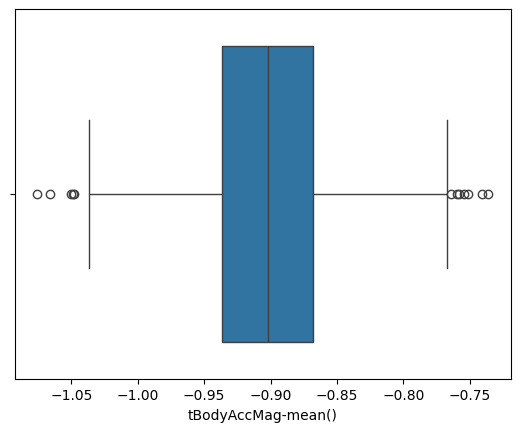

In [34]:
standing_df = df[df['activity'] == 'STANDING']

sns.boxplot(data=standing_df, x='tBodyAccMag-mean()')

In [ ]:
존재

4.

<Axes: xlabel='tBodyAcc-std()-X', ylabel='Count'>

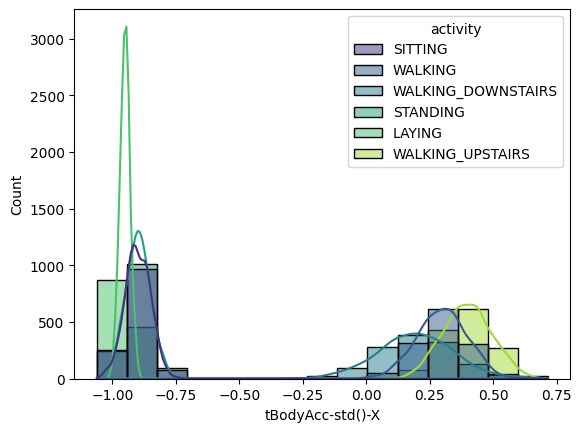

In [35]:
sns.histplot(data=df, x='tBodyAcc-std()-X', hue='activity', kde=True, palette='viridis')

In [ ]:
LAYING

5.

In [36]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.

#대상 컬럼을 정의하세요.
nan_cols = ['tBodyAcc-std()-Y', 'tGravityAcc-mean()-Z', 'tBodyGyro-mean()-X', 'fBodyAcc-mean()-Y', 'angle(X,gravityMean)']

# 빈칸을 채워 결측치 보간을 완료하고 결과를 확인하세요.
for col in nan_cols:
    df[col] = df[col].fillna(df[col].median())

# 최종 결측치 합계 확인
print(df.isnull().sum().sum())

0


6.

In [37]:
# (6-1) 여기에 코드의 오류를 정정하고 실행하세요.
Q1 = df['tBodyAccMag-mean()'].quantile(0.25)
Q3 = df['tBodyAccMag-mean()'].quantile(0.75)
IQR = Q3 - Q1

lower_boundary = Q1 - 1.5 * IQR
upper_boundary = Q3 + 1.5 * IQR

df = df[(df['tBodyAccMag-mean()'] >= lower_boundary) & (df['tBodyAccMag-mean()'] <= upper_boundary)]

print(len(df))

7990


In [ ]:
7990

7.

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['activity'] = le.fit_transform(df['activity'])

# 1. 인코딩된 고유 숫자값 출력
print("인코딩된 고유값:", df['activity'].unique())

# 2. 숫자값과 매칭되는 원래 클래스 확인
print("원래 클래스명:", le.classes_)

인코딩된 고유값: [1 3 4 2 0 5]
원래 클래스명: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [ ]:
6

8.

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['activity'])
y = df['activity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

9.

In [40]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()

X_train_scaled = rs.fit_transform(X_train)
X_test_scaled = rs.transform(X_test)

10.

In [41]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)

lr = LogisticRegression(C=0.1, max_iter=50, random_state=42)

gb.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, max_iter=50, random_state=42)

11.

In [42]:
# (11-1) 여기에 코드의 오류를 정정하고 실행하세요.

from sklearn.metrics import f1_score

pred_gb = gb.predict(X_test_scaled)
f1_gb = f1_score(y_test, pred_gb, average='weighted')

pred_lr = lr.predict(X_test_scaled)
f1_lr = f1_score(y_test, pred_lr, average='weighted')

print(f"LR F1-score: {f1_lr:.4f}")
print(f"GB F1-score: {f1_gb:.4f}")

LR F1-score: 0.6902
GB F1-score: 0.7868


In [ ]:
GradientBoostingClassifier

12.

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(42)

In [44]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요
dl_model = Sequential()
dl_model.add(Dense(units=32, activation='relu',input_shape=(X_train_scaled.shape[1],)))
dl_model.add(Dropout(0.3))
dl_model.add(Dense(units=16, activation='relu'))
dl_model.add(Dropout(0.2))
dl_model.add(Dense(units=8, activation='relu'))
dl_model.add(Dense(6, activation='softmax'))

dl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10)
mc = ModelCheckpoint('best_activity_model.keras', monitor='val_loss', save_best_only=True)

history = dl_model.fit(X_train_scaled, y_train,
                       epochs=200, batch_size=32,
                       validation_data=(X_test_scaled, y_test),
                       callbacks=[es, mc])

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1895 - loss: 1.7886 - val_accuracy: 0.2534 - val_loss: 1.7097
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3079 - loss: 1.5130 - val_accuracy: 0.4086 - val_loss: 1.2022
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3916 - loss: 1.1783 - val_accuracy: 0.4631 - val_loss: 1.0410
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4421 - loss: 1.0771 - val_accuracy: 0.5432 - val_loss: 0.9715
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4972 - loss: 0.9979 - val_accuracy: 0.6402 - val_loss: 0.8619
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5515 - loss: 0.9192 - val_accuracy: 0.6946 - val_loss: 0.7622
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5918 - loss: 0.8517 - val_accuracy: 0.7021 - val_loss: 0.7109
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6231 - loss: 0.8064 - val_accuracy: 0.7090

13.

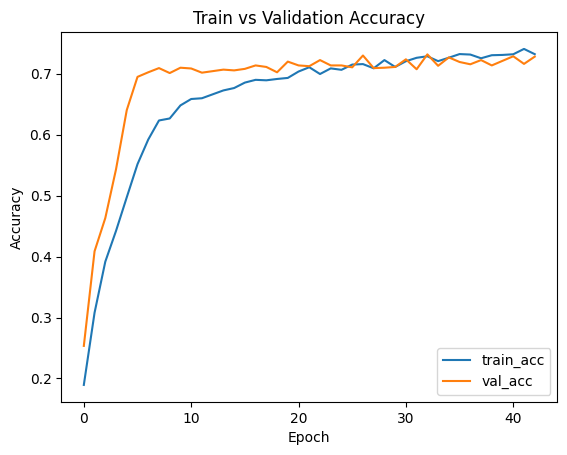

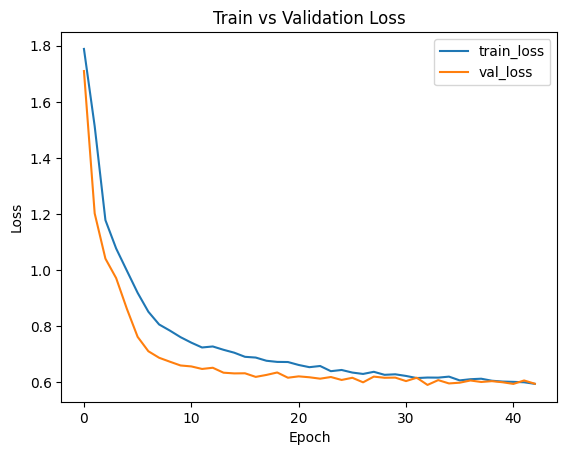

In [45]:
# (13-1) 제공된 시각화 코드를 실행하여 학습 결과를 확인하세요.
# ----- 1. 정확도 시각화 -----
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.show()

# ----- 2. 손실 시각화 -----
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.show()

14.

In [46]:
# (14-1) 여기에 답안코드를 작성하고 실행하세요.
# 보검이의 실시간 생체 신호 데이터(스케일링 처리 완료)
new_data=np.array([[-0.30220005,  0.45768456,  1.80021891, -0.66791508,  0.29523195,
         0.71789722,  1.17549744,  0.40061864, -0.59636902, -0.06873771,
        -0.70462027, -1.62872918,  0.0735179 , -0.95773435, -0.66899568,
        -0.39573429, -0.88419615, -0.00998886, -0.20019575,  1.65011582,
         0.53200416, -0.01193946, -0.03656269, -0.00767125, -0.15099404]])

In [47]:
best_model = load_model('best_activity_model.keras')

pred = best_model.predict(new_data)

pred_idx = np.argmax(pred, axis=1)

pred_scaled = le.inverse_transform(pred_idx)

print(pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
['LAYING']
